In [2]:
import torch
import matplotlib.pyplot as plt
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)
from pathlib import Path

from src.io import load_dataset
from src.training.split import split_subjects
from src.dataset import OCTLayerDataset
from src.models.unet import UNet
from src.visualization import show_oct, show_mask

/Users/philipabakah/Desktop/projects/explore/oct-retinal-layer-segmentation


In [3]:
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

mps


In [4]:
subjects = load_dataset("../datasets/duke/2015_BOE_Chiu")

train_subjects, val_subjects = split_subjects(subjects)

In [5]:
val_dataset = OCTLayerDataset(
    val_subjects,
    grader=1,
)

print(len(val_dataset))

22


In [6]:
model = UNet(
    n_channels=1,
    n_classes=8,
)

model.load_state_dict(
    torch.load(
        "../checkpoints/best_model.pth",
        map_location=device,
    )
)

model.to(device)

model.eval()

UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): DownBlock(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [7]:
image, mask = val_dataset[0]

print(image.shape)
print(mask.shape)

torch.Size([1, 496, 768])
torch.Size([496, 768])


In [8]:
with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(device)
    )

prediction.shape

torch.Size([1, 8, 496, 768])

In [9]:
prediction = prediction.argmax(dim=1)

prediction = prediction.squeeze(0).cpu()

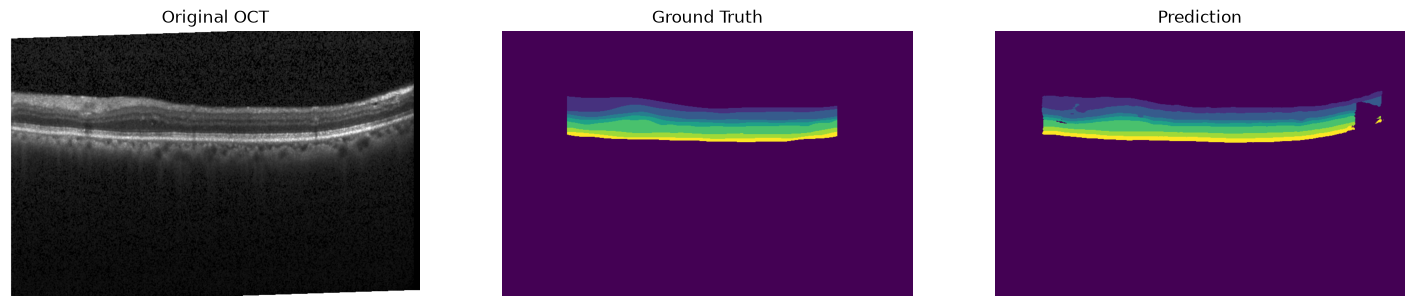

In [10]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title("Original OCT")
plt.imshow(image.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(prediction)
plt.axis("off")

plt.show()

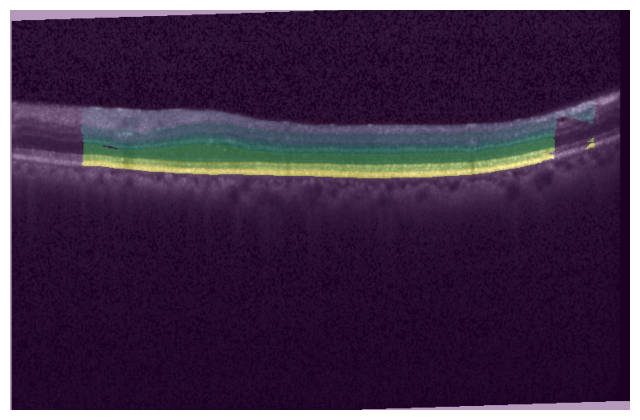

In [11]:
plt.figure(figsize=(8,8))

plt.imshow(
    image.squeeze(),
    cmap="gray",
)

plt.imshow(
    prediction,
    alpha=0.4,
)

plt.axis("off")

plt.show()